In [ ]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import os
import random
import shutil
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================
# CELL 2: DOWNLOAD GTSRB DATASET
# ============================================
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ibrahimkaratas/gtsrb-german-traffic-sign-recognition-benchmark")

print("Path to dataset files:", path)

100%|██████████| 231M/231M [00:06<00:00, 39.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ibrahimkaratas/gtsrb-german-traffic-sign-recognition-benchmark/versions/1


In [ ]:
# ============================================
# CELL 3: DATASET PATH
# ============================================

train_path = os.path.join(path, "Train")

print("Training dataset path:")
print(train_path)

print("\nFolders inside Train:")
print(os.listdir(train_path)[:10])

Training dataset path:
/root/.cache/kagglehub/datasets/ibrahimkaratas/gtsrb-german-traffic-sign-recognition-benchmark/versions/1/Train

Folders inside Train:
['8', '22', '14', '19', '12', '28', '13', '23', '3', '4']


In [ ]:
# ============================================
# CELL 4: IDENTIFY CLASSES
# ============================================

classes = sorted(
    [
        folder
        for folder in os.listdir(train_path)
        if os.path.isdir(os.path.join(train_path, folder))
    ],
    key=int
)

num_classes = len(classes)

print("Number of classes:", num_classes)
print("Classes:", classes)

Number of classes: 43
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42']


In [ ]:
# ============================================
# CELL 5: CLASS DISTRIBUTION
# ============================================

class_counts = {}

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    image_count = len(
        [
            file
            for file in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, file))
        ]
    )

    class_counts[int(class_name)] = image_count


class_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

print(class_distribution)
print("\nTotal images:", class_distribution["Number of Images"].sum())

    Class  Number of Images
0       0               210
1       1              2220
2       2              2250
3       3              1410
4       4              1980
5       5              1860
6       6               420
7       7              1440
8       8              1410
9       9              1470
10     10              2010
11     11              1320
12     12              2100
13     13              2160
14     14               780
15     15               630
16     16               420
17     17              1110
18     18              1200
19     19               210
20     20               360
21     21               330
22     22               390
23     23               510
24     24               270
25     25              1500
26     26               600
27     27               240
28     28               540
29     29               270
30     30               450
31     31               780
32     32               240
33     33               689
34     34           

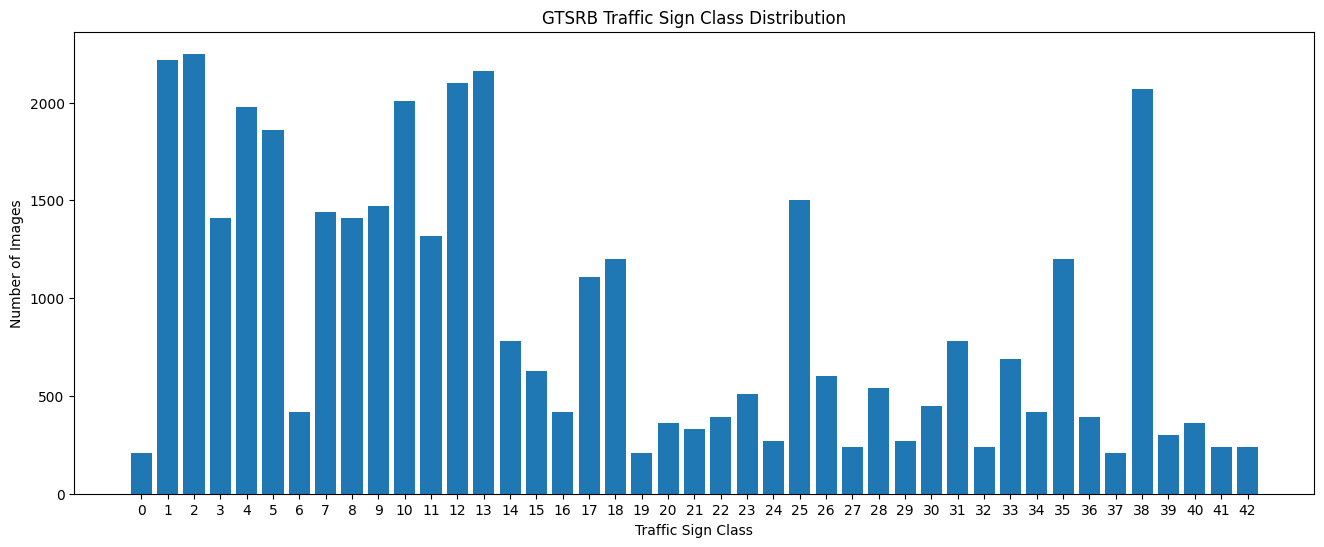

In [ ]:
# ============================================
# CELL 6: CLASS DISTRIBUTION GRAPH
# ============================================

plt.figure(figsize=(16, 6))

plt.bar(
    class_distribution["Class"],
    class_distribution["Number of Images"]
)

plt.xlabel("Traffic Sign Class")
plt.ylabel("Number of Images")
plt.title("GTSRB Traffic Sign Class Distribution")

plt.xticks(range(num_classes))

plt.show()

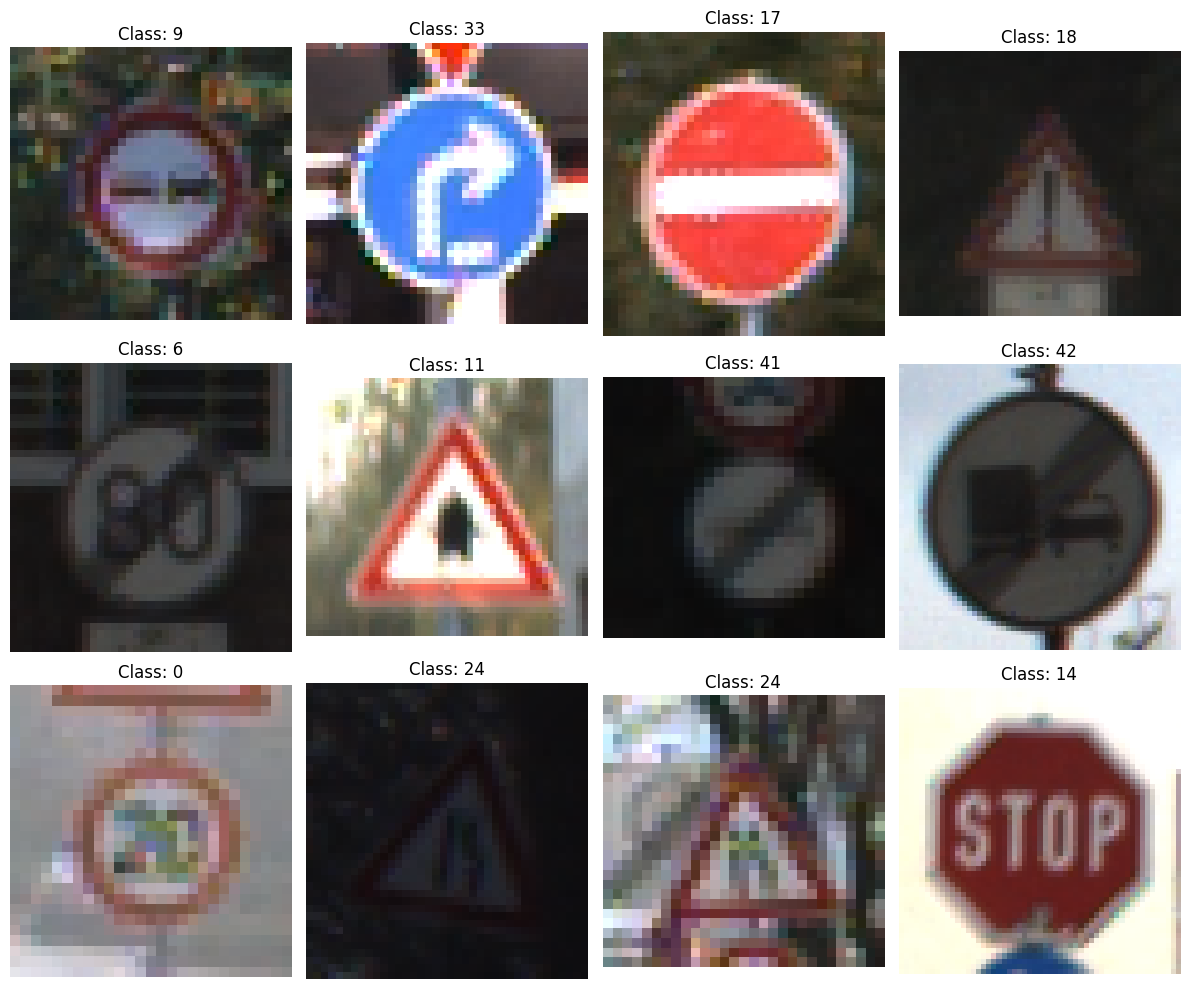

In [ ]:
# ============================================
# CELL 7: DISPLAY SAMPLE IMAGES
# ============================================

plt.figure(figsize=(12, 10))

for i in range(12):

    class_name = random.choice(classes)

    class_path = os.path.join(train_path, class_name)

    image_name = random.choice(os.listdir(class_path))

    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(f"Class: {class_name}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL 8: CHECK IMAGE SIZES
# ============================================

image_sizes = []

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    image_files = os.listdir(class_path)[:20]

    for image_name in image_files:

        image_path = os.path.join(
            class_path,
            image_name
        )

        image = cv2.imread(image_path)

        if image is not None:

            height, width = image.shape[:2]

            image_sizes.append(
                (width, height)
            )


size_counts = pd.Series(
    image_sizes
).value_counts()


print("Most common image sizes:")

print(size_counts.head(10))

Most common image sizes:
(38, 38)    11
(39, 38)     9
(33, 32)     9
(37, 38)     9
(33, 33)     9
(27, 28)     9
(29, 29)     9
(32, 32)     8
(35, 34)     8
(38, 37)     8
Name: count, dtype: int64


In [ ]:
# ============================================
# CELL 9: LOAD ALL IMAGES
# ============================================

IMG_SIZE = 32

images = []
labels = []

print("Loading images...")

for class_name in classes:

    class_path = os.path.join(
        train_path,
        class_name
    )

    for image_name in os.listdir(class_path):

        image_path = os.path.join(
            class_path,
            image_name
        )

        image = cv2.imread(image_path)

        if image is None:
            continue

        # Convert BGR to RGB
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # Resize image
        image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE)
        )

        images.append(image)

        labels.append(
            int(class_name)
        )


print("Finished loading images!")

Loading images...
Finished loading images!


In [ ]:
# ============================================
# CELL 10: CONVERT TO NUMPY ARRAYS
# ============================================

X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of classes:", len(np.unique(y)))
print("Unique labels:", np.unique(y))

X shape: (39209, 32, 32, 3)
y shape: (39209,)

Number of classes: 43
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


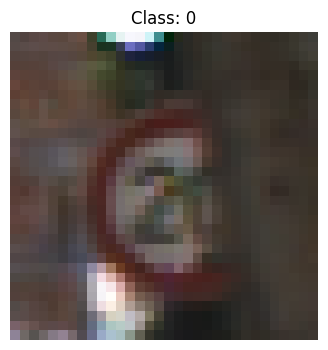

Image shape: (32, 32, 3)
Pixel minimum: 1
Pixel maximum: 255


In [ ]:
# ============================================
# CELL 11: CHECK PROCESSED IMAGE
# ============================================

index = 0

plt.figure(figsize=(4, 4))

plt.imshow(X[index])

plt.title(
    f"Class: {y[index]}"
)

plt.axis("off")

plt.show()

print("Image shape:", X[index].shape)
print("Pixel minimum:", X[index].min())
print("Pixel maximum:", X[index].max())

In [ ]:
# ============================================
# CELL 12: NORMALIZATION
# ============================================

X = X.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
# ============================================
# CELL 13: TRAIN / VALIDATION SPLIT
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", X_train.shape)
print("Validation images:", X_val.shape)

print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)

Training images: (31367, 32, 32, 3)
Validation images: (7842, 32, 32, 3)
Training labels: (31367,)
Validation labels: (7842,)


In [ ]:
# ============================================
# CELL 14: FREE MEMORY
# ============================================

del images
del labels

print("Original image lists deleted.")

Original image lists deleted.


In [ ]:
# ============================================
# CELL 15: DATA AUGMENTATION
# ============================================

data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(
            height_factor=0.10,
            width_factor=0.10
        )
    ],
    name="data_augmentation"
)

print("Data augmentation created.")

Data augmentation created.


In [ ]:
# ============================================
# CELL 16: BUILD CNN MODEL
# ============================================

model = keras.Sequential(
    [

        # Input
        layers.Input(
            shape=(IMG_SIZE, IMG_SIZE, 3)
        ),

        # Data augmentation
        data_augmentation,

        # CNN Block 1
        layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        # CNN Block 2
        layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        # CNN Block 3
        layers.Conv2D(
            128,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        # Convert feature maps to vector
        layers.Flatten(),

        # Fully connected layer
        layers.Dense(
            128,
            activation="relu"
        ),

        # Regularization
        layers.Dropout(0.5),

        # Output layer
        layers.Dense(
            num_classes,
            activation="softmax"
        )
    ]
)

In [ ]:
# ============================================
# CELL 17: MODEL SUMMARY
# ============================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# CELL 18: COMPILE MODEL
# ============================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# ============================================
# CELL 19: EARLY STOPPING
# ============================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Early stopping configured.")

Early stopping configured.


In [ ]:
# ============================================
# CELL 20: TRAIN MODEL
# ============================================

history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    batch_size=64,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.2116 - loss: 2.8526 - val_accuracy: 0.4311 - val_loss: 1.8148
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4145 - loss: 1.8485 - val_accuracy: 0.6061 - val_loss: 1.2035
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5236 - loss: 1.4160 - val_accuracy: 0.7029 - val_loss: 0.8707
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6091 - loss: 1.1458 - val_accuracy: 0.7952 - val_loss: 0.6167
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6782 - loss: 0.9519 - val_accuracy: 0.8518 - val_loss: 0.4760
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7320 - loss: 0.7926 - val_accuracy: 0.8986 - val_loss: 0.3199
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7719 - loss: 0.6753 - val_accuracy: 0.9231 - val_loss: 0.2529
Epoch 8/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8115 - loss: 0.5644 - val_accurac

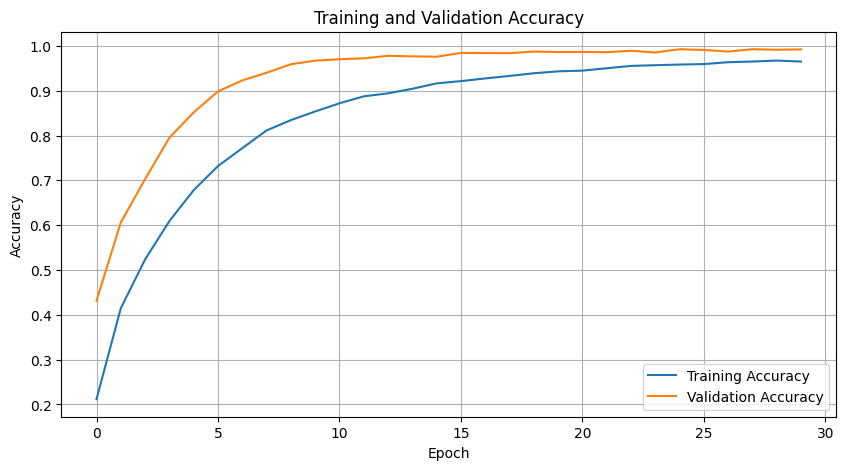

In [ ]:
# ============================================
# CELL 21: ACCURACY GRAPH
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

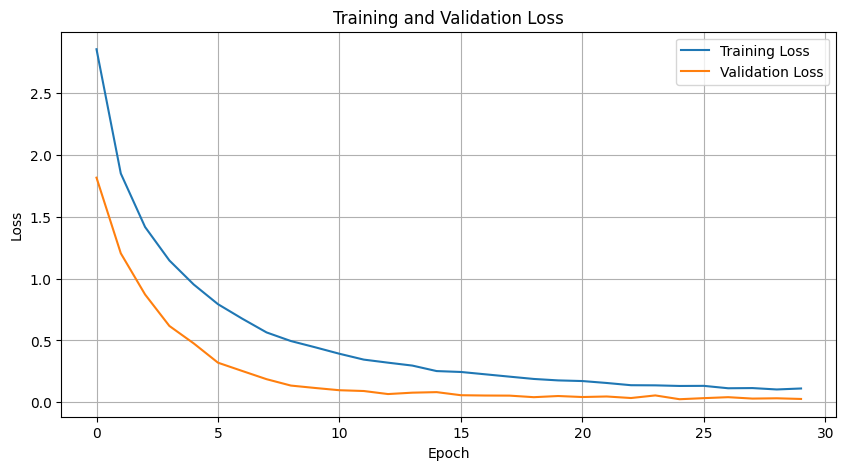

In [ ]:
# ============================================
# CELL 22: LOSS GRAPH
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================
# CELL 23: MODEL EVALUATION
# ============================================

val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=1
)

print("\nValidation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9927 - loss: 0.0248

Validation Loss: 0.024767186492681503
Validation Accuracy: 0.9927314519882202


In [ ]:
# ============================================
# CELL 24: GENERATE PREDICTIONS
# ============================================

y_pred_probabilities = model.predict(
    X_val,
    batch_size=64,
    verbose=1
)

y_pred = np.argmax(
    y_pred_probabilities,
    axis=1
)

print("Predictions generated.")
print("Prediction shape:", y_pred.shape)

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predictions generated.
Prediction shape: (7842,)


In [ ]:
# ============================================
# CELL 25: CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_val,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    0.9286    0.9630        42
           1     0.9908    0.9752    0.9830       444
           2     0.9635    0.9978    0.9803       450
           3     0.9892    0.9752    0.9821       282
           4     0.9949    0.9949    0.9949       396
           5     0.9865    0.9839    0.9852       372
           6     1.0000    1.0000    1.0000        84
           7     0.9965    0.9792    0.9877       288
           8     0.9790    0.9929    0.9859       282
           9     1.0000    1.0000    1.0000       294
          10     1.0000    0.9975    0.9988       402
          11     0.9925    0.9962    0.9943       264
          12     1.0000    0.9976    0.9988       420
          13     0.9977    1.0000    0.9988       432
          14     1.0000    1.0000    1.0000       156
          15     1.0000    0.9921    0.9960       126
          16     1.0000    1.0000    1.0000        84
          17     1.0000    

In [ ]:
# ============================================
# CELL 26: OVERALL ACCURACY
# ============================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

print(
    f"Validation Accuracy: {accuracy * 100:.2f}%"
)

Validation Accuracy: 99.27%


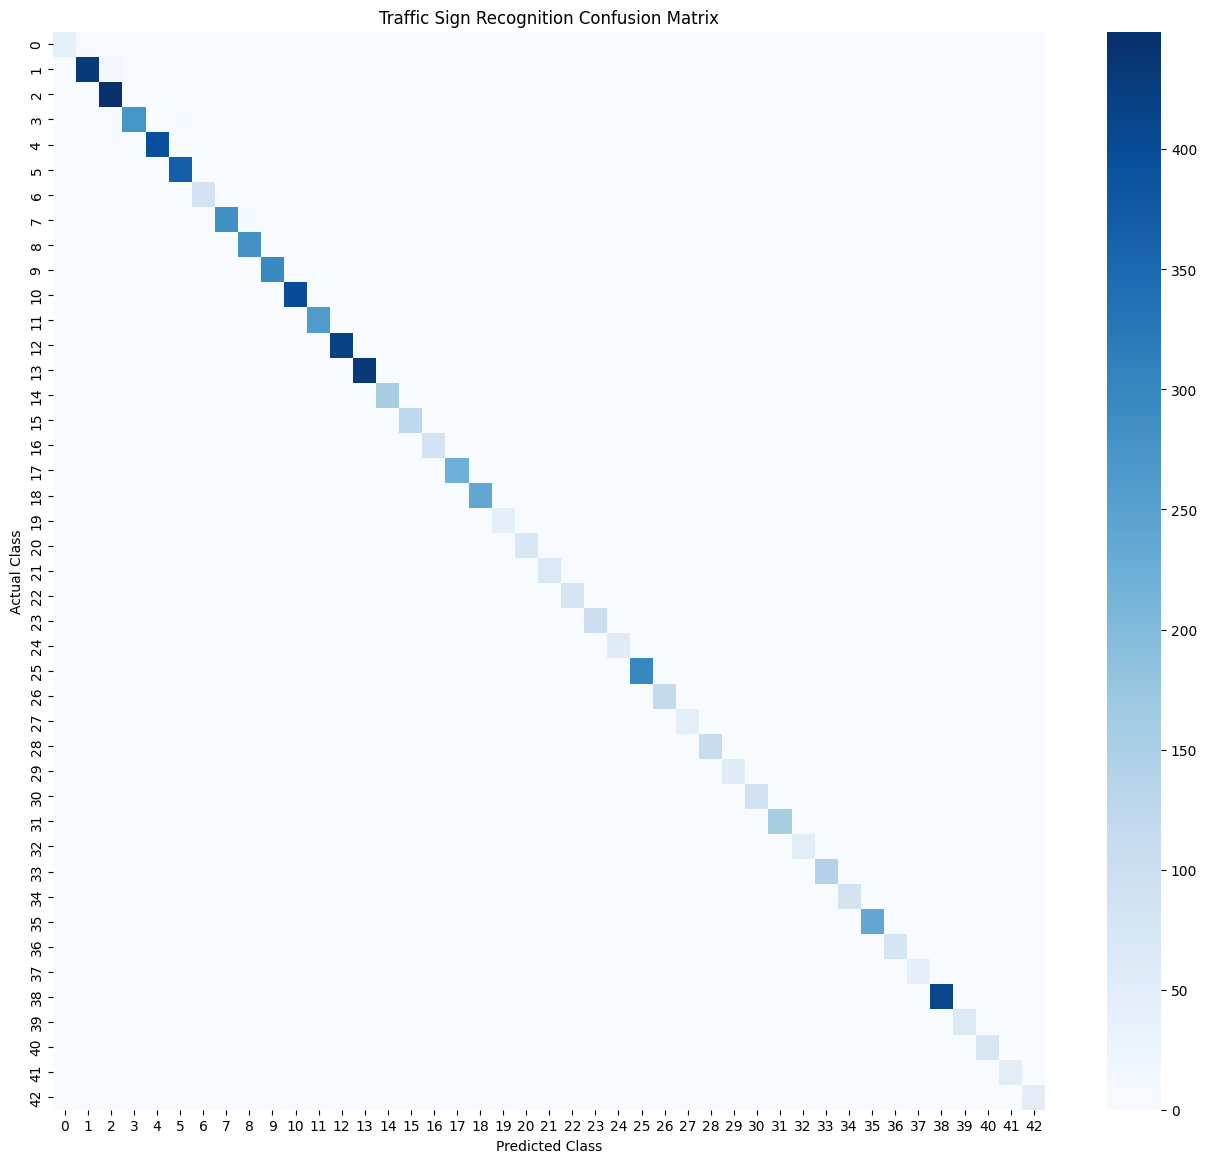

In [ ]:
# ============================================
# CELL 27: CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_val,
    y_pred
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=False,
    fmt="d"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Traffic Sign Recognition Confusion Matrix"
)

plt.show()

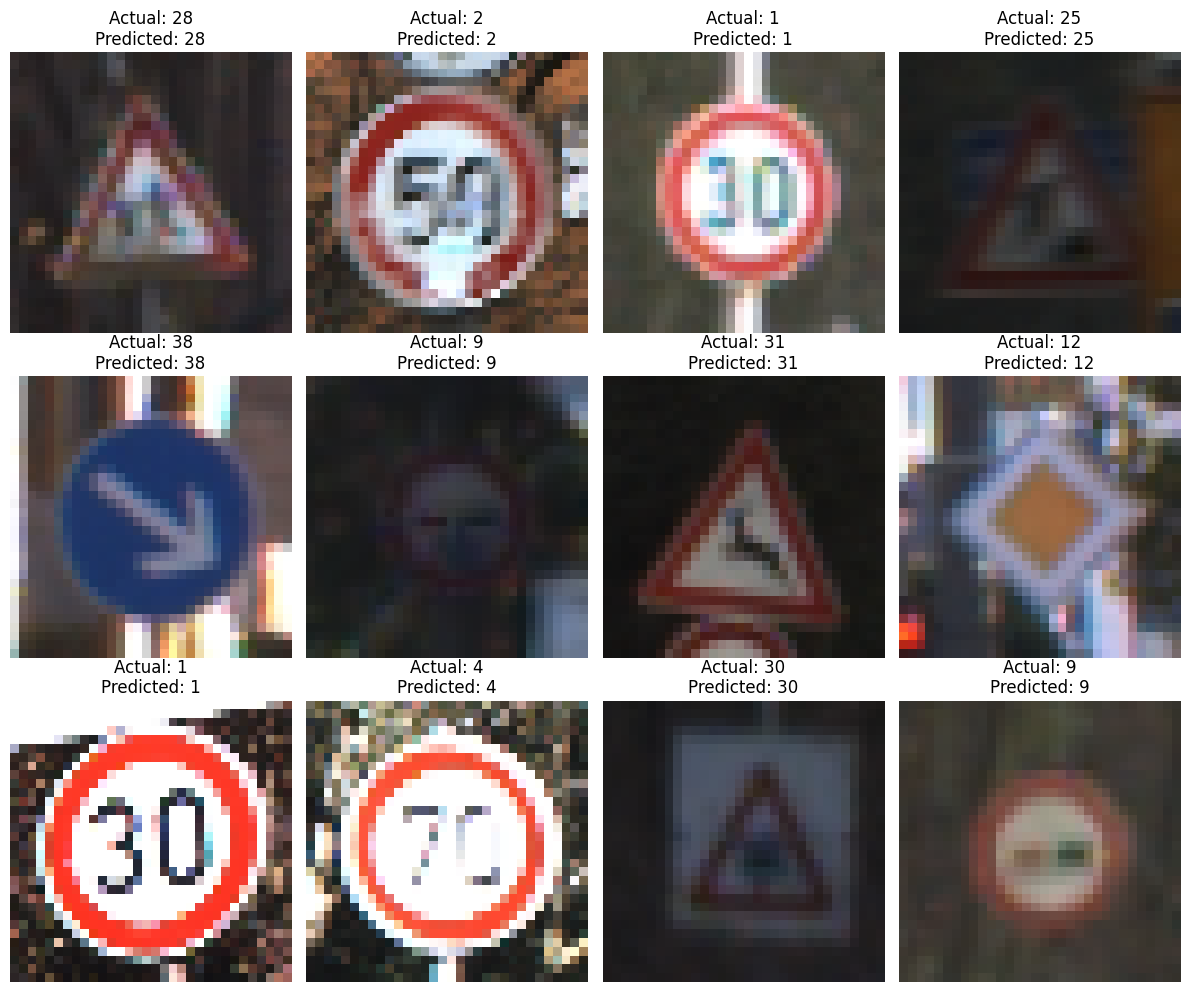

In [ ]:
# ============================================
# CELL 28: CORRECT PREDICTIONS
# ============================================

correct_indices = np.where(
    y_pred == y_val
)[0]

plt.figure(figsize=(12, 10))

for i, index in enumerate(
    correct_indices[:12]
):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_val[index])

    plt.title(
        f"Actual: {y_val[index]}\n"
        f"Predicted: {y_pred[index]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

Number of incorrect predictions: 57


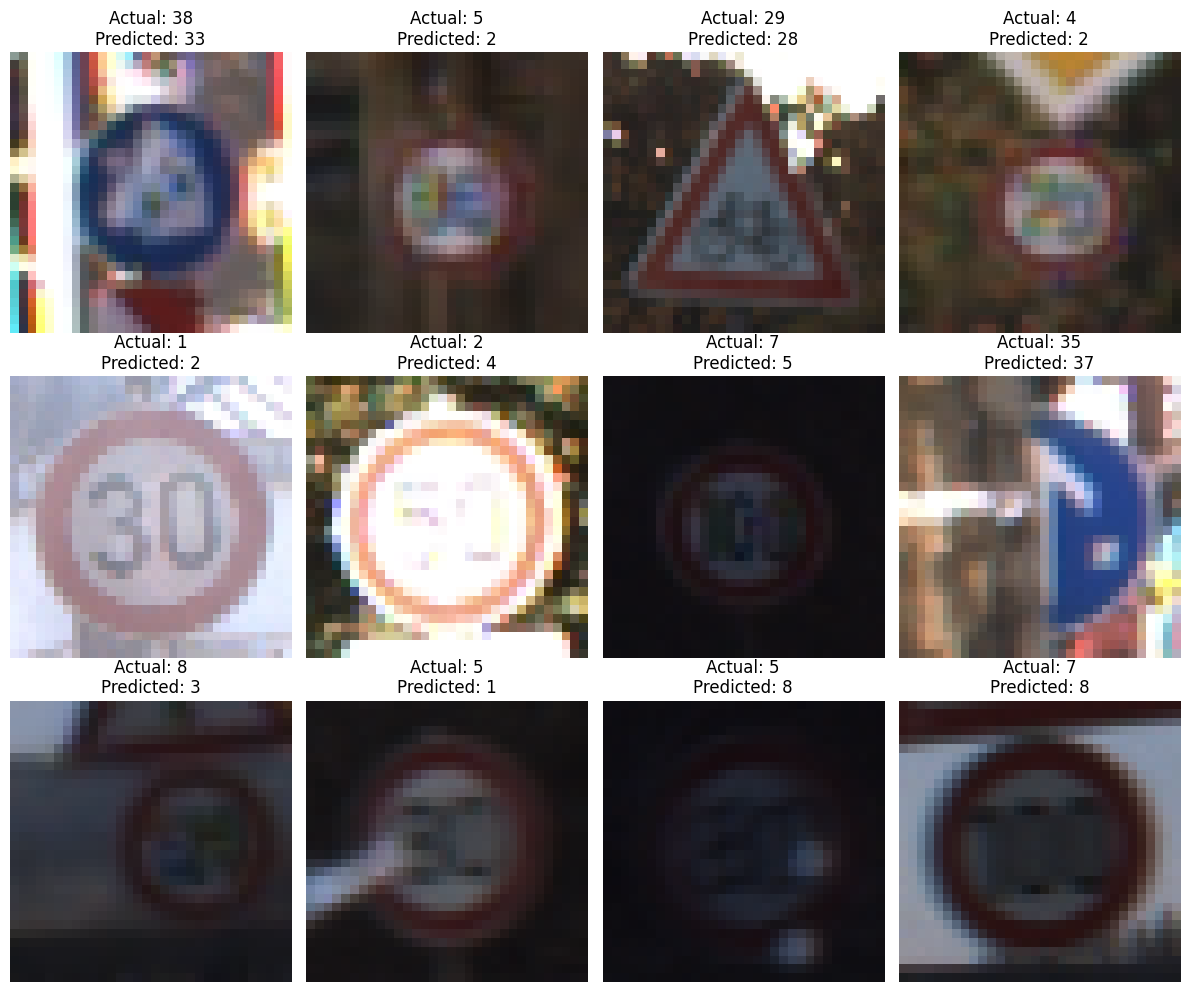

In [ ]:
# ============================================
# CELL 29: INCORRECT PREDICTIONS
# ============================================

incorrect_indices = np.where(
    y_pred != y_val
)[0]

print(
    "Number of incorrect predictions:",
    len(incorrect_indices)
)

plt.figure(figsize=(12, 10))

for i, index in enumerate(
    incorrect_indices[:12]
):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_val[index])

    plt.title(
        f"Actual: {y_val[index]}\n"
        f"Predicted: {y_pred[index]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# CELL 30: TRAFFIC SIGN CLASS NAMES
# ============================================

class_names = [
    "Speed limit (20km/h)",
    "Speed limit (30km/h)",
    "Speed limit (50km/h)",
    "Speed limit (60km/h)",
    "Speed limit (70km/h)",
    "Speed limit (80km/h)",
    "End of speed limit (80km/h)",
    "Speed limit (100km/h)",
    "Speed limit (120km/h)",
    "No passing",
    "No passing for vehicles over 3.5 tons",
    "Right-of-way at next intersection",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "Vehicles over 3.5 tons prohibited",
    "No entry",
    "General caution",
    "Dangerous curve left",
    "Dangerous curve right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows on the right",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycles crossing",
    "Beware of ice/snow",
    "Wild animals crossing",
    "End of all speed and passing limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Go straight or right",
    "Go straight or left",
    "Keep right",
    "Keep left",
    "Roundabout mandatory",
    "End of no passing",
    "End of no passing by vehicles over 3.5 tons"
]

print("Number of class names:", len(class_names))

Number of class names: 43


In [ ]:
# ============================================
# CELL 31: CLASSIFICATION REPORT WITH NAMES
# ============================================

print(
    classification_report(
        y_val,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                                             precision    recall  f1-score   support

                       Speed limit (20km/h)     1.0000    0.9286    0.9630        42
                       Speed limit (30km/h)     0.9908    0.9752    0.9830       444
                       Speed limit (50km/h)     0.9635    0.9978    0.9803       450
                       Speed limit (60km/h)     0.9892    0.9752    0.9821       282
                       Speed limit (70km/h)     0.9949    0.9949    0.9949       396
                       Speed limit (80km/h)     0.9865    0.9839    0.9852       372
                End of speed limit (80km/h)     1.0000    1.0000    1.0000        84
                      Speed limit (100km/h)     0.9965    0.9792    0.9877       288
                      Speed limit (120km/h)     0.9790    0.9929    0.9859       282
                                 No passing     1.0000    1.0000    1.0000       294
      No passing for vehicles over 3.5 tons     1.0000    0.9975

In [ ]:
# ============================================
# CELL 32: SAVE TRAINED MODEL
# ============================================

MODEL_PATH = "/content/traffic_sign_cnn.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
/content/traffic_sign_cnn.keras


In [ ]:
# ============================================
# CELL 33: SAVE CLASS NAMES
# ============================================

CLASS_NAMES_PATH = "/content/class_names.json"

with open(
    CLASS_NAMES_PATH,
    "w"
) as f:

    json.dump(
        class_names,
        f
    )

print("Class names saved!")

Class names saved!


In [ ]:
# ============================================
# CELL 34: SINGLE IMAGE PREDICTION
# ============================================

def predict_traffic_sign(image_path):

    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(
            "Could not read the image."
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    original_image = image.copy()

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image.astype(
        "float32"
    ) / 255.0

    image = np.expand_dims(
        image,
        axis=0
    )

    probabilities = model.predict(
        image,
        verbose=0
    )[0]

    predicted_class = np.argmax(
        probabilities
    )

    confidence = probabilities[
        predicted_class
    ]

    return (
        original_image,
        predicted_class,
        confidence
    )

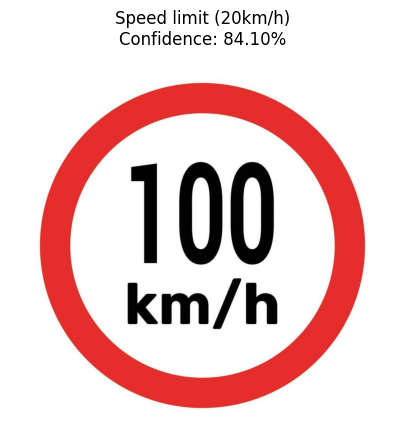

In [ ]:
image, predicted_class, confidence = predict_traffic_sign(
    "/content/speed-limit-sign-100-km-h-icon-illustration-vector.jpg"
)

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    f"{class_names[predicted_class]}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()

In [ ]:
# ============================================
# CELL 35: DOWNLOAD MODEL FILES
# ============================================

from google.colab import files

files.download(
    "/content/traffic_sign_cnn.keras"
)

files.download(
    "/content/class_names.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>